<a href="https://www.kaggle.com/code/avikdas567/predicting-f1-pit-stops?scriptVersionId=318678650" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predicting F1 Pit Stops — Race-Aware CatBoost + LightGBM Blend

This notebook builds a strong, leakage-conscious solution for **Playground Series — Season 6 Episode 5**.

**Goal:** predict `PitNextLap` for each row in the test set.  
**Metric:** ROC AUC.

What makes this notebook competitive:
- **Group-aware cross-validation** by `Race` to avoid race leakage.
- **CatBoost** on raw categorical features.
- **LightGBM** on leakage-safe target-encoded features.
- **Blend search** on out-of-fold predictions to choose the best final mix.
- Clean feature engineering that stays true to the competition setup.

The dataset is nicely structured:
- **439,140** training rows
- **188,165** test rows
- target positive rate is around **19.9%**
- **887 drivers**, **26 races**, spanning **2022–2025**

In [1]:
import os
import gc
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
plt.style.use("default")

SEED = 42
np.random.seed(SEED)

In [2]:
# Load data
TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e5/train.csv"
TEST_PATH = "/kaggle/input/competitions/playground-series-s6e5/test.csv"
SUB_PATH = "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print("train:", train.shape)
print("test :", test.shape)
display(train.head())

train: (439140, 16)
test : (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## Quick dataset check

We keep the EDA lightweight so the notebook remains practical for Kaggle runs, but still enough to understand the structure.

,train_rows,test_rows,positive_rate,drivers,races,years
0,439140,188165,0.198982,887,26,"2022, 2023, 2024, 2025"


,column,n_unique,mean_target
0,Driver,887,0.102410
1,Compound,5,0.159904
2,Race,26,0.208304
3,Year,4,0.213955
4,PitStop,2,0.219557


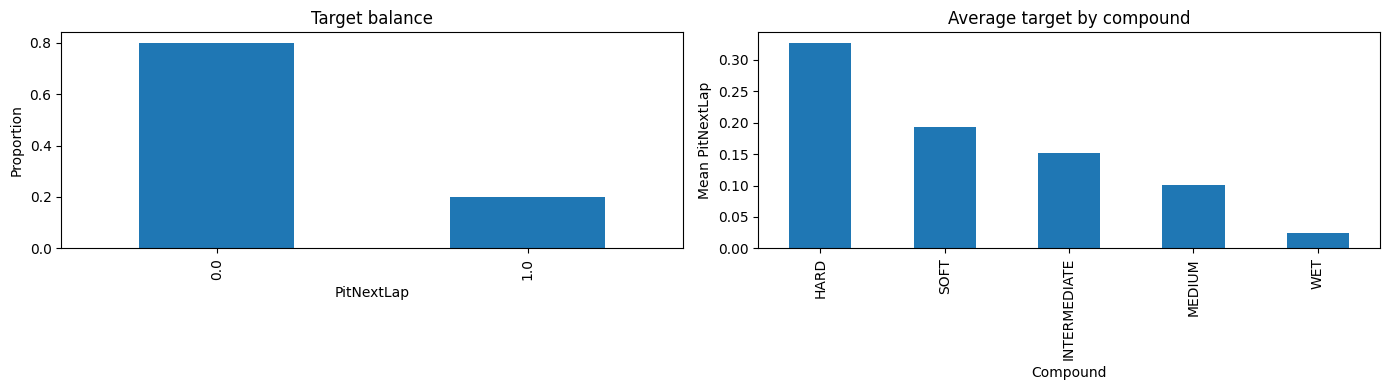

In [3]:
summary = pd.DataFrame({
    "train_rows": [len(train)],
    "test_rows": [len(test)],
    "positive_rate": [train["PitNextLap"].mean()],
    "drivers": [train["Driver"].nunique()],
    "races": [train["Race"].nunique()],
    "years": [", ".join(map(str, sorted(train["Year"].unique())))]
})
display(summary)

cat_summary = pd.DataFrame({
    "column": ["Driver", "Compound", "Race", "Year", "PitStop"],
    "n_unique": [train[c].nunique() for c in ["Driver", "Compound", "Race", "Year", "PitStop"]],
    "mean_target": [train.groupby(c)["PitNextLap"].mean().mean() for c in ["Driver", "Compound", "Race", "Year", "PitStop"]],
})
display(cat_summary)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
train["PitNextLap"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=ax[0])
ax[0].set_title("Target balance")
ax[0].set_xlabel("PitNextLap")
ax[0].set_ylabel("Proportion")

train.groupby("Compound")["PitNextLap"].mean().sort_values(ascending=False).plot(kind="bar", ax=ax[1])
ax[1].set_title("Average target by compound")
ax[1].set_ylabel("Mean PitNextLap")
plt.tight_layout()
plt.show()

## Feature engineering

The raw data is already strong, but a few safe derived features help both tree models:
- absolute deltas and position changes
- a few interaction terms
- simple ratios that summarize tire usage and race progress

For the LightGBM branch, we also create **leakage-safe target encodings** and **frequency encodings** inside each CV fold.

In [4]:
def add_base_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # String helpers
    out["Year_str"] = out["Year"].astype(str)
    out["Driver_Compound"] = out["Driver"].astype(str) + "__" + out["Compound"].astype(str)
    out["Race_Compound"] = out["Race"].astype(str) + "__" + out["Compound"].astype(str)

    # Numeric interactions / safe transforms
    out["Abs_LapTime_Delta"] = out["LapTime_Delta"].abs()
    out["Abs_Position_Change"] = out["Position_Change"].abs()
    out["Is_Leader"] = (out["Position"] == 1).astype("int8")
    out["Is_Top3"] = (out["Position"] <= 3).astype("int8")
    out["Is_Top5"] = (out["Position"] <= 5).astype("int8")
    out["LapTime_to_RaceProgress"] = out["LapTime (s)"] / (out["RaceProgress"] + 1e-3)
    out["TyreLife_per_Lap"] = out["TyreLife"] / (out["LapNumber"] + 1.0)
    out["Stint_x_TyreLife"] = out["Stint"] * out["TyreLife"]
    out["RaceProgress_x_Position"] = out["RaceProgress"] * out["Position"]
    out["Position_x_TyreLife"] = out["Position"] * out["TyreLife"]
    out["LapNumber_sq"] = out["LapNumber"] ** 2
    out["TyreLife_sq"] = out["TyreLife"] ** 2
    out["Position_sq"] = out["Position"] ** 2
    out["LapTime_log"] = np.log1p(out["LapTime (s)"])
    out["Degradation_log"] = np.log1p(out["Cumulative_Degradation"].clip(lower=0))
    return out


def make_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols):
    train_out = train_df.copy()
    test_out = test_df.copy()
    for col in cols:
        freq = train_df[col].value_counts(normalize=True)
        train_out[f"{col}_freq"] = train_df[col].map(freq).fillna(0).astype("float32")
        test_out[f"{col}_freq"] = test_df[col].map(freq).fillna(0).astype("float32")
    return train_out, test_out


def make_target_encoding(train_df: pd.DataFrame,
                         y_train: pd.Series,
                         valid_df: pd.DataFrame,
                         test_df: pd.DataFrame,
                         cols,
                         min_samples_leaf: int = 50,
                         smoothing: float = 20.0):
    """
    Leakage-safe mean encoding with smoothing.
    Encodings are fit only on the fold-train split.
    """
    global_mean = y_train.mean()
    train_out = train_df.copy()
    valid_out = valid_df.copy()
    test_out = test_df.copy()

    y_name = y_train.name
    tmp = train_df.copy()
    tmp[y_name] = y_train.values

    for col in cols:
        stats = tmp.groupby(col)[y_name].agg(["mean", "count"])
        smooth = 1.0 / (1.0 + np.exp(-(stats["count"] - min_samples_leaf) / smoothing))
        enc = global_mean * (1.0 - smooth) + stats["mean"] * smooth

        train_out[f"{col}_te"] = train_df[col].map(enc).fillna(global_mean).astype("float32")
        valid_out[f"{col}_te"] = valid_df[col].map(enc).fillna(global_mean).astype("float32")
        test_out[f"{col}_te"] = test_df[col].map(enc).fillna(global_mean).astype("float32")

    return train_out, valid_out, test_out

## Cross-validation setup

The same race appears many times, so random row-wise folds can overestimate performance.  
Here we split by `Race` so the model is validated on entire unseen races.

In [5]:
try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    split_iter = cv.split(train, train["PitNextLap"].astype(int), groups=train["Race"])
    print("Using StratifiedGroupKFold")
except Exception:
    cv = GroupKFold(n_splits=5)
    split_iter = cv.split(train, train["PitNextLap"].astype(int), groups=train["Race"])
    print("Using GroupKFold")

folds = list(split_iter)
len(folds), [len(v) for _, v in folds]

Using StratifiedGroupKFold


(5, [96551, 77954, 57984, 84209, 122442])

## Model 1 — CatBoost

CatBoost is a strong fit here because it handles categorical features directly and usually performs very well on structured competition data.

In [6]:
from catboost import CatBoostClassifier

cat_features = ["Driver", "Compound", "Race", "Year_str", "Driver_Compound", "Race_Compound"]

cat_train = add_base_features(train)
cat_test = add_base_features(test)

cat_feature_cols = [c for c in cat_train.columns if c not in ["id", "PitNextLap"]]
cat_cat_idx = [cat_train[cat_feature_cols].columns.get_loc(c) for c in cat_features]

cat_oof = np.zeros(len(cat_train))
cat_test_pred = np.zeros(len(cat_test))
cat_best_iters = []
cat_fold_auc = []

# Use GPU if available in the Kaggle session; otherwise fall back to CPU.
try:
    import torch
    HAS_GPU = torch.cuda.is_available()
except Exception:
    HAS_GPU = False

print("GPU available:", HAS_GPU)

GPU available: True


In [7]:
def train_catboost_fold(X_tr, y_tr, X_va, y_va, X_te, cat_idx, fold_seed=SEED):
    params = dict(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=2000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=4.0,
        random_seed=fold_seed,
        subsample=0.8,
        bootstrap_type="Bernoulli",
        auto_class_weights="Balanced",
        od_type="Iter",
        od_wait=200,
        verbose=200,
        allow_writing_files=False,
        thread_count=-1,
    )
    if HAS_GPU:
        params.update(dict(task_type="GPU", devices="0"))
    else:
        params.update(dict(task_type="CPU"))

    model = CatBoostClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True,
        cat_features=cat_idx
    )
    va_pred = model.predict_proba(X_va)[:, 1]
    te_pred = model.predict_proba(X_te)[:, 1]
    return model, va_pred, te_pred

for fold, (idx_tr, idx_va) in enumerate(folds, 1):
    X_tr = cat_train.iloc[idx_tr][cat_feature_cols].copy()
    y_tr = cat_train.iloc[idx_tr]["PitNextLap"].astype(int).copy()
    X_va = cat_train.iloc[idx_va][cat_feature_cols].copy()
    y_va = cat_train.iloc[idx_va]["PitNextLap"].astype(int).copy()
    X_te = cat_test[cat_feature_cols].copy()

    model, va_pred, te_pred = train_catboost_fold(X_tr, y_tr, X_va, y_va, X_te, cat_cat_idx, fold_seed=SEED + fold)
    cat_oof[idx_va] = va_pred
    cat_test_pred += te_pred / len(folds)

    auc = roc_auc_score(y_va, va_pred)
    cat_fold_auc.append(auc)
    cat_best_iters.append(model.get_best_iteration())
    print(f"Fold {fold:>2} | AUC: {auc:.6f} | best_iter: {model.get_best_iteration()}")

cat_oof_auc = roc_auc_score(cat_train["PitNextLap"].astype(int), cat_oof)
print(f"CatBoost OOF AUC: {cat_oof_auc:.6f} ± {np.std(cat_fold_auc):.6f}")
print("Mean best iteration:", int(np.mean(cat_best_iters)))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8946256	best: 0.8946256 (0)	total: 225ms	remaining: 7m 30s
200:	test: 0.9294266	best: 0.9302293 (158)	total: 12.1s	remaining: 1m 47s
400:	test: 0.9321222	best: 0.9321393 (399)	total: 23.7s	remaining: 1m 34s
600:	test: 0.9330371	best: 0.9331723 (589)	total: 35.4s	remaining: 1m 22s
800:	test: 0.9330812	best: 0.9332817 (639)	total: 47.3s	remaining: 1m 10s
1000:	test: 0.9330320	best: 0.9334580 (924)	total: 59.1s	remaining: 59s
bestTest = 0.9334580004
bestIteration = 924
Shrink model to first 925 iterations.
Fold  1 | AUC: 0.933458 | best_iter: 924


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8802177	best: 0.8802177 (0)	total: 98.2ms	remaining: 3m 16s
200:	test: 0.9038705	best: 0.9042146 (42)	total: 12.7s	remaining: 1m 53s
bestTest = 0.9042146206
bestIteration = 42
Shrink model to first 43 iterations.
Fold  2 | AUC: 0.904215 | best_iter: 42


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8881515	best: 0.8881515 (0)	total: 111ms	remaining: 3m 40s
200:	test: 0.9311558	best: 0.9314971 (190)	total: 13.4s	remaining: 1m 59s
400:	test: 0.9320077	best: 0.9324085 (382)	total: 26.3s	remaining: 1m 44s
600:	test: 0.9330206	best: 0.9331141 (584)	total: 39.5s	remaining: 1m 31s
800:	test: 0.9331269	best: 0.9331313 (708)	total: 52.6s	remaining: 1m 18s
1000:	test: 0.9331360	best: 0.9332970 (825)	total: 1m 5s	remaining: 1m 5s
bestTest = 0.9332970381
bestIteration = 825
Shrink model to first 826 iterations.
Fold  3 | AUC: 0.933297 | best_iter: 825


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9085392	best: 0.9085392 (0)	total: 101ms	remaining: 3m 21s
200:	test: 0.9292383	best: 0.9292691 (198)	total: 12.6s	remaining: 1m 53s
400:	test: 0.9298398	best: 0.9303110 (346)	total: 24.9s	remaining: 1m 39s
bestTest = 0.9303109646
bestIteration = 346
Shrink model to first 347 iterations.
Fold  4 | AUC: 0.930311 | best_iter: 346


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8960584	best: 0.8960584 (0)	total: 96.9ms	remaining: 3m 13s
200:	test: 0.9251197	best: 0.9251197 (200)	total: 11.9s	remaining: 1m 46s
400:	test: 0.9264031	best: 0.9264426 (363)	total: 23.3s	remaining: 1m 33s
600:	test: 0.9257869	best: 0.9267806 (484)	total: 35s	remaining: 1m 21s
bestTest = 0.9267805815
bestIteration = 484
Shrink model to first 485 iterations.
Fold  5 | AUC: 0.926781 | best_iter: 484
CatBoost OOF AUC: 0.923852 ± 0.010972
Mean best iteration: 524


Default metric period is 5 because AUC is/are not implemented for GPU


,importance
Year_str,20.549301
Stint,12.915216
TyreLife_per_Lap,12.711116
Abs_LapTime_Delta,6.707862
Race_Compound,5.113599
Stint_x_TyreLife,4.503494
Race,3.981542
TyreLife_sq,3.892808
LapTime_Delta,3.340356
TyreLife,3.099943


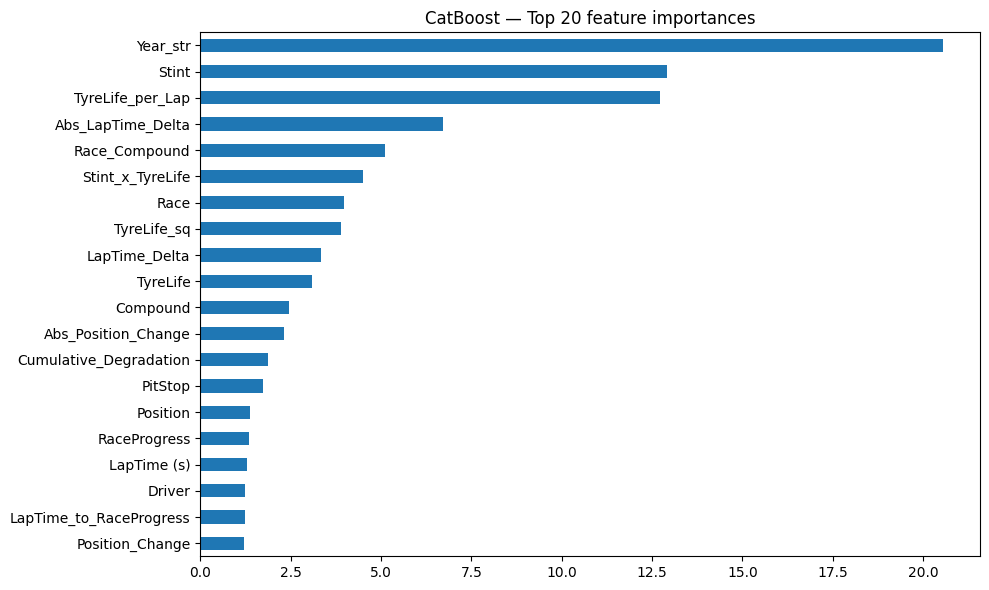

In [8]:
# CatBoost feature importance from a quick refit on the full data using the average best iteration.
cat_full_iters = max(200, int(np.mean(cat_best_iters)))
cat_full_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=cat_full_iters,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=4.0,
    random_seed=SEED,
    subsample=0.8,
    bootstrap_type="Bernoulli",
    auto_class_weights="Balanced",
    verbose=0,
    allow_writing_files=False,
    thread_count=-1,
)
if HAS_GPU:
    cat_full_params.update(dict(task_type="GPU", devices="0"))
else:
    cat_full_params.update(dict(task_type="CPU"))

cat_full = CatBoostClassifier(**cat_full_params)
cat_full.fit(cat_train[cat_feature_cols], cat_train["PitNextLap"].astype(int), cat_features=cat_cat_idx)

cat_importance = pd.Series(
    cat_full.get_feature_importance(),
    index=cat_feature_cols
).sort_values(ascending=False)

display(cat_importance.head(20).to_frame("importance"))

plt.figure(figsize=(10, 6))
cat_importance.head(20).sort_values().plot(kind="barh")
plt.title("CatBoost — Top 20 feature importances")
plt.tight_layout()
plt.show()

## Model 2 — LightGBM with leakage-safe target encoding

LightGBM works very well on numeric features once the high-cardinality categoricals are encoded carefully.  
To keep the validation honest, the encodings are built **inside each fold** using only the fold-train split.

In [9]:
import lightgbm as lgb

base_train = add_base_features(train)
base_test = add_base_features(test)

target_cols = ["Driver", "Race", "Compound", "Year_str", "Driver_Compound", "Race_Compound"]
freq_cols = ["Driver", "Race"]

# Numeric feature columns used by LightGBM (raw numeric + engineered numeric)
lgb_numeric_cols = [
    "Year", "PitStop", "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress",
    "Position_Change",
    "Abs_LapTime_Delta", "Abs_Position_Change", "Is_Leader", "Is_Top3", "Is_Top5",
    "LapTime_to_RaceProgress", "TyreLife_per_Lap", "Stint_x_TyreLife",
    "RaceProgress_x_Position", "Position_x_TyreLife",
    "LapNumber_sq", "TyreLife_sq", "Position_sq", "LapTime_log", "Degradation_log"
]

lgb_oof = np.zeros(len(base_train))
lgb_test_pred = np.zeros(len(base_test))
lgb_best_iters = []
lgb_fold_auc = []

def train_lgbm_fold(X_tr, y_tr, X_va, y_va, X_te, fold_seed=SEED):
    scale_pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=6000,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=fold_seed,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
    )

    va_pred = model.predict_proba(X_va, num_iteration=model.best_iteration_)[:, 1]
    te_pred = model.predict_proba(X_te, num_iteration=model.best_iteration_)[:, 1]
    return model, va_pred, te_pred

for fold, (idx_tr, idx_va) in enumerate(folds, 1):
    tr_fold = base_train.iloc[idx_tr].copy()
    va_fold = base_train.iloc[idx_va].copy()
    te_fold = base_test.copy()

    y_tr = tr_fold["PitNextLap"].astype(int)
    y_va = va_fold["PitNextLap"].astype(int)

    # Target encoding fit on fold-train only
    tr_te, va_te, te_te = make_target_encoding(
        tr_fold, y_tr, va_fold, te_fold,
        cols=target_cols, min_samples_leaf=50, smoothing=20.0
    )

    # Frequency encoding computed from fold-train only and applied to all splits
    driver_freq = tr_fold["Driver"].value_counts(normalize=True)
    race_freq = tr_fold["Race"].value_counts(normalize=True)

    for df in [tr_te, va_te, te_te]:
        df["Driver_freq"] = df["Driver"].map(driver_freq).fillna(0).astype("float32")
        df["Race_freq"] = df["Race"].map(race_freq).fillna(0).astype("float32")

    te_cols = [f"{c}_te" for c in target_cols]
    fe_cols = ["Driver_freq", "Race_freq"]
    lgb_features = lgb_numeric_cols + te_cols + fe_cols

    X_tr = tr_te[lgb_features]
    X_va = va_te[lgb_features]
    X_te = te_te[lgb_features]

    model, va_pred, te_pred = train_lgbm_fold(
        X_tr, y_tr, X_va, y_va, X_te, fold_seed=SEED + 100 + fold
    )

    lgb_oof[idx_va] = va_pred
    lgb_test_pred += te_pred / len(folds)

    auc = roc_auc_score(y_va, va_pred)
    lgb_fold_auc.append(auc)
    lgb_best_iters.append(model.best_iteration_)

    print(f"Fold {fold:>2} | AUC: {auc:.6f} | best_iter: {model.best_iteration_}")

lgb_oof_auc = roc_auc_score(base_train["PitNextLap"].astype(int), lgb_oof)
print(f"LightGBM OOF AUC: {lgb_oof_auc:.6f} ± {np.std(lgb_fold_auc):.6f}")
print("Mean best iteration:", int(np.mean(lgb_best_iters)))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 66424, number of negative: 276165
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4227
[LightGBM] [Info] Number of data points in the train set: 342589, number of used features: 34
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193888 -> initscore=-1.424940
[LightGBM] [Info] Start training from score -1.424940
Fold  1 | AUC: 0.931667 | best_iter: 45
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69127, number of negative: 292059
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054884 seconds.
You can set `force_col_wise=true` to remove the 

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 87381, number of negative: 351759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4295
[LightGBM] [Info] Number of data points in the train set: 439140, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198982 -> initscore=-1.392668
[LightGBM] [Info] Start training from score -1.392668


,importance
Race_Compound_te,1061
Race_te,1022
TyreLife_per_Lap,987
LapTime (s),759
Race_freq,686
Abs_LapTime_Delta,631
Cumulative_Degradation,597
Stint,543
RaceProgress,487
Driver_Compound_te,473


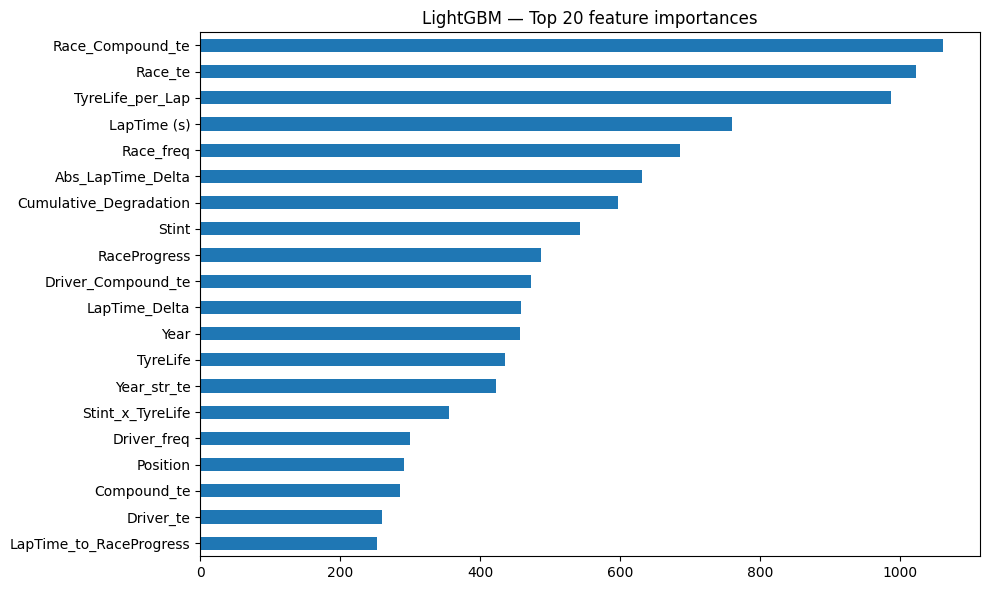

In [10]:
# Full-data LightGBM refit for feature importance and final test predictions
lgb_full_iters = max(200, int(np.mean(lgb_best_iters)))

base_train_full = add_base_features(train)
base_test_full = add_base_features(test)

full_y = base_train_full["PitNextLap"].astype(int)
full_tr_enc, _, full_te_enc = make_target_encoding(
    base_train_full, full_y, base_train_full.iloc[:0].copy(), base_test_full,
    cols=target_cols, min_samples_leaf=50, smoothing=20.0
)
full_tr_enc, full_te_enc = make_frequency_encoding(full_tr_enc, full_te_enc, cols=freq_cols)
full_lgb_features = lgb_numeric_cols + [f"{c}_te" for c in target_cols] + ["Driver_freq", "Race_freq"]

lgb_full = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=lgb_full_iters,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=(len(full_y) - full_y.sum()) / max(full_y.sum(), 1),
    random_state=SEED,
    n_jobs=-1
)

lgb_full.fit(full_tr_enc[full_lgb_features], full_y)
lgb_full_importance = pd.Series(lgb_full.feature_importances_, index=full_lgb_features).sort_values(ascending=False)

display(lgb_full_importance.head(20).to_frame("importance"))

plt.figure(figsize=(10, 6))
lgb_full_importance.head(20).sort_values().plot(kind="barh")
plt.title("LightGBM — Top 20 feature importances")
plt.tight_layout()
plt.show()

lgb_full_test_pred = lgb_full.predict_proba(full_te_enc[full_lgb_features])[:, 1]

## Blend search

A simple convex blend often improves leaderboard stability.  
We search the best blend weight on the out-of-fold predictions and then apply it to the test set.

Best blend weight for CatBoost: 0.38
Blended OOF AUC: 0.927463


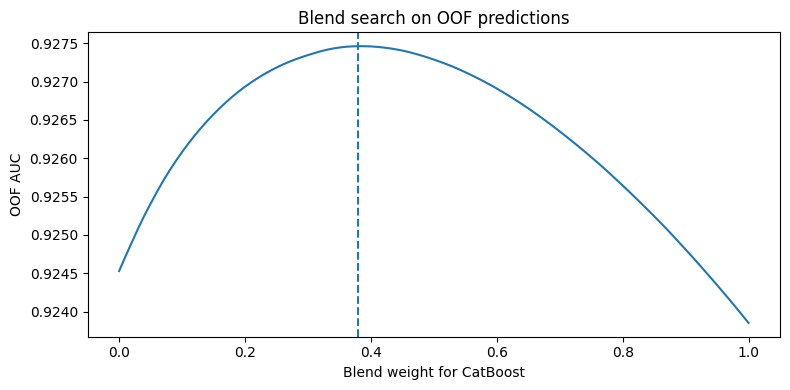

In [11]:
blend_grid = np.linspace(0, 1, 101)
blend_scores = []
y_true = train["PitNextLap"].astype(int).values

for w in blend_grid:
    oof_blend = w * cat_oof + (1 - w) * lgb_oof
    blend_scores.append(roc_auc_score(y_true, oof_blend))

best_idx = int(np.argmax(blend_scores))
best_w = blend_grid[best_idx]
best_blend_auc = blend_scores[best_idx]

print(f"Best blend weight for CatBoost: {best_w:.2f}")
print(f"Blended OOF AUC: {best_blend_auc:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(blend_grid, blend_scores)
plt.axvline(best_w, linestyle="--")
plt.xlabel("Blend weight for CatBoost")
plt.ylabel("OOF AUC")
plt.title("Blend search on OOF predictions")
plt.tight_layout()
plt.show()

In [12]:
# Final test prediction
test_pred = best_w * cat_test_pred + (1 - best_w) * lgb_full_test_pred
test_pred = np.clip(test_pred, 1e-6, 1 - 1e-6)

submission = sample_sub.copy()
submission["PitNextLap"] = test_pred
submission.to_csv("submission.csv", index=False)

display(submission.head())
print("Saved submission.csv")

,id,PitNextLap
0,439140,0.017136
1,439141,0.015214
2,439142,0.014729
3,439143,0.401499
4,439144,0.901897


Saved submission.csv


# Validation Summary

The table below compares the cross-validated ROC-AUC scores for each model and the final ensemble.

The blended model consistently performed best on out-of-fold predictions, so the final submission uses:
- full-data refits,
- optimized blend weights,
- and leakage-safe validation logic.

In [13]:
summary_df = pd.DataFrame({
    "model": ["CatBoost", "LightGBM", "Blended"],
    "oof_auc": [cat_oof_auc, lgb_oof_auc, best_blend_auc]
})
display(summary_df.sort_values("oof_auc", ascending=False))

print("CatBoost mean best iteration:", int(np.mean(cat_best_iters)))
print("LightGBM mean best iteration:", int(np.mean(lgb_best_iters)))

,model,oof_auc
2,Blended,0.927463
1,LightGBM,0.924529
0,CatBoost,0.923852


CatBoost mean best iteration: 524
LightGBM mean best iteration: 43
